In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import requests
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Configuration
CSV_PATH = 'matched_SMALL.csv'
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.cache = {}  # Dictionary to store {idx: tensor_image}
        self.headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Check if we've already downloaded and transformed this image
        if idx in self.cache:
            image_tensor, label_tensor = self.cache[idx]
            return image_tensor, label_tensor

        # 2. If not in cache, do the standard fetch
        url = self.dataframe.iloc[idx]['image_url']
        label = int(self.dataframe.iloc[idx]['high_reorder'])
        
        try:
            response = requests.get(url, headers=self.headers, timeout=10)
            response.raise_for_status()
            image = Image.open(BytesIO(response.content)).convert('RGB')
        except Exception as e:
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color=(128, 128, 128))
            
        if self.transform:
            image = self.transform(image)
        
        label_tensor = torch.tensor(label, dtype=torch.float32)

        # 3. Save to cache before returning
        self.cache[idx] = (image, label_tensor)
            
        return image, label_tensor

# Preprocessing Pipeline (same as before)
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load and Split Data
df = pd.read_csv(CSV_PATH)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

train_loader = DataLoader(ImageDataset(train_df, transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ImageDataset(val_df, transform), batch_size=BATCH_SIZE)
test_loader = DataLoader(ImageDataset(test_df, transform), batch_size=BATCH_SIZE)

print(f"Dataset Split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Dataset Split: Train=94, Val=20, Test=21


In [4]:
def train_model(model, criterion, optimizer, num_epochs=EPOCHS):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).view(-1, 1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

def evaluate_model(model):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).view(-1, 1)
            outputs = torch.sigmoid(model(inputs))
            probs = outputs.cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int)) # Force labels to int here

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc = roc_auc_score(all_labels, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"\n--- Evaluation Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC:  {roc:.4f}")
    print(f"Confusion Matrix:\n{cm}")

def get_best_worst_indices(model, loader, n=3):
    model.eval()
    results = []
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(loader):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            labels = labels.cpu().numpy().flatten()
            
            for j in range(len(probs)):
                # Calculate absolute error
                error = np.abs(probs[j] - labels[j])
                results.append({
                    'index': i * BATCH_SIZE + j,
                    'prob': probs[j],
                    'label': labels[j],
                    'error': error
                })
    
    df_res = pd.DataFrame(results)
    
    # Best: Lowest error
    best = df_res.sort_values(by='error').head(n)
    # Worst: Highest error
    worst = df_res.sort_values(by='error', ascending=False).head(n)
    
    return best, worst

# Example usage for your best model:
# best_indices, worst_indices = get_best_worst_indices(model_rn18_ft, test_loader)

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model_cnn = SimpleCNN().to(DEVICE)
optimizer = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

print("Training Custom CNN...")
train_model(model_cnn, criterion, optimizer)
evaluate_model(model_cnn)

Training Custom CNN...
Epoch 1/10, Loss: 4.9324
Epoch 2/10, Loss: 1.8806
Epoch 3/10, Loss: 0.7501
Epoch 4/10, Loss: 0.6316
Epoch 5/10, Loss: 0.6303
Epoch 6/10, Loss: 0.6116
Epoch 7/10, Loss: 0.5993
Epoch 8/10, Loss: 0.5854
Epoch 9/10, Loss: 0.5668
Epoch 10/10, Loss: 0.5421

--- Evaluation Results ---
Accuracy: 0.5714
F1 Score: 0.7273
ROC-AUC:  0.5926
Confusion Matrix:
[[ 0  9]
 [ 0 12]]


In [6]:
model_rn18_scratch = models.resnet18(weights=None)
model_rn18_scratch.fc = nn.Linear(model_rn18_scratch.fc.in_features, 1)
model_rn18_scratch = model_rn18_scratch.to(DEVICE)

optimizer = optim.Adam(model_rn18_scratch.parameters(), lr=LEARNING_RATE)
print("Training ResNet-18 from scratch...")
train_model(model_rn18_scratch, criterion, optimizer)
evaluate_model(model_rn18_scratch)

Training ResNet-18 from scratch...
Epoch 1/10, Loss: 1.3551
Epoch 2/10, Loss: 0.8750
Epoch 3/10, Loss: 0.7291
Epoch 4/10, Loss: 0.5773
Epoch 5/10, Loss: 0.5068
Epoch 6/10, Loss: 0.4622
Epoch 7/10, Loss: 0.4461
Epoch 8/10, Loss: 0.3509
Epoch 9/10, Loss: 0.2700
Epoch 10/10, Loss: 0.2153

--- Evaluation Results ---
Accuracy: 0.6190
F1 Score: 0.6923
ROC-AUC:  0.6759
Confusion Matrix:
[[4 5]
 [3 9]]


In [7]:
model_rn18_frozen = models.resnet18(weights='DEFAULT')
# Freeze all layers
for param in model_rn18_frozen.parameters():
    param.requires_grad = False

# Replace head (new layers are trainable by default)
model_rn18_frozen.fc = nn.Linear(model_rn18_frozen.fc.in_features, 1)
model_rn18_frozen = model_rn18_frozen.to(DEVICE)

optimizer = optim.Adam(model_rn18_frozen.fc.parameters(), lr=LEARNING_RATE)
print("Training Pretrained ResNet-18 (Frozen)...")
train_model(model_rn18_frozen, criterion, optimizer)
evaluate_model(model_rn18_frozen)

Training Pretrained ResNet-18 (Frozen)...
Epoch 1/10, Loss: 0.7264
Epoch 2/10, Loss: 0.6950
Epoch 3/10, Loss: 0.6734
Epoch 4/10, Loss: 0.6389
Epoch 5/10, Loss: 0.6259
Epoch 6/10, Loss: 0.6068
Epoch 7/10, Loss: 0.5908
Epoch 8/10, Loss: 0.5674
Epoch 9/10, Loss: 0.5490
Epoch 10/10, Loss: 0.5465

--- Evaluation Results ---
Accuracy: 0.5714
F1 Score: 0.7097
ROC-AUC:  0.6481
Confusion Matrix:
[[ 1  8]
 [ 1 11]]


In [8]:
model_rn18_ft = models.resnet18(weights='DEFAULT')
model_rn18_ft.fc = nn.Linear(model_rn18_ft.fc.in_features, 1)
model_rn18_ft = model_rn18_ft.to(DEVICE)

# Use a smaller learning rate for fine-tuning to avoid wrecking pretrained weights
optimizer = optim.Adam(model_rn18_ft.parameters(), lr=1e-5)
print("Training Pretrained ResNet-18 (Fine-tuned)...")
train_model(model_rn18_ft, criterion, optimizer)
evaluate_model(model_rn18_ft)

Training Pretrained ResNet-18 (Fine-tuned)...
Epoch 1/10, Loss: 0.8035
Epoch 2/10, Loss: 0.7402
Epoch 3/10, Loss: 0.6938
Epoch 4/10, Loss: 0.6409
Epoch 5/10, Loss: 0.5783
Epoch 6/10, Loss: 0.5435
Epoch 7/10, Loss: 0.5152
Epoch 8/10, Loss: 0.4604
Epoch 9/10, Loss: 0.4354
Epoch 10/10, Loss: 0.3964

--- Evaluation Results ---
Accuracy: 0.5714
F1 Score: 0.5263
ROC-AUC:  0.6852
Confusion Matrix:
[[7 2]
 [7 5]]


In [9]:
model_vit_frozen = models.vit_b_16(weights='DEFAULT')
for param in model_vit_frozen.parameters():
    param.requires_grad = False

# ViT head is called 'heads'
model_vit_frozen.heads = nn.Sequential(nn.Linear(model_vit_frozen.heads[0].in_features, 1))
model_vit_frozen = model_vit_frozen.to(DEVICE)

optimizer = optim.Adam(model_vit_frozen.heads.parameters(), lr=LEARNING_RATE)
print("Training Pretrained ViT-B/16 (Frozen)...")
train_model(model_vit_frozen, criterion, optimizer)
evaluate_model(model_vit_frozen)

Training Pretrained ViT-B/16 (Frozen)...
Epoch 1/10, Loss: 0.6946
Epoch 2/10, Loss: 0.6275
Epoch 3/10, Loss: 0.6003
Epoch 4/10, Loss: 0.5691
Epoch 5/10, Loss: 0.5466
Epoch 6/10, Loss: 0.5236
Epoch 7/10, Loss: 0.5034
Epoch 8/10, Loss: 0.4836
Epoch 9/10, Loss: 0.4653
Epoch 10/10, Loss: 0.4470

--- Evaluation Results ---
Accuracy: 0.5238
F1 Score: 0.6429
ROC-AUC:  0.4259
Confusion Matrix:
[[2 7]
 [3 9]]


In [10]:
model_vit_ft = models.vit_b_16(weights='DEFAULT')
model_vit_ft.heads = nn.Sequential(nn.Linear(model_vit_ft.heads[0].in_features, 1))
model_vit_ft = model_vit_ft.to(DEVICE)

# Very small learning rate for ViT fine-tuning
optimizer = optim.Adam(model_vit_ft.parameters(), lr=1e-6)
print("Training Pretrained ViT-B/16 (Fine-tuned)...")
train_model(model_vit_ft, criterion, optimizer)
evaluate_model(model_vit_ft)

Training Pretrained ViT-B/16 (Fine-tuned)...
Epoch 1/10, Loss: 0.7175
Epoch 2/10, Loss: 0.6940
Epoch 3/10, Loss: 0.6756
Epoch 4/10, Loss: 0.6557
Epoch 5/10, Loss: 0.6402
Epoch 6/10, Loss: 0.6274
Epoch 7/10, Loss: 0.6148
Epoch 8/10, Loss: 0.6026
Epoch 9/10, Loss: 0.5918
Epoch 10/10, Loss: 0.5814

--- Evaluation Results ---
Accuracy: 0.5238
F1 Score: 0.6667
ROC-AUC:  0.4444
Confusion Matrix:
[[ 1  8]
 [ 2 10]]


In [11]:
def collect_metrics(model, model_name, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int))

    # Calculate metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc = roc_auc_score(all_labels, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    
    # Flatten confusion matrix for the CSV (TN, FP, FN, TP)
    tn, fp, fn, tp = cm.ravel()
    
    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1_Score": f1,
        "ROC_AUC": roc,
        "True_Negative": tn,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Positive": tp
    }

# 1. Create a list of your models and their display names
model_list = [
    (model_cnn, "Custom CNN"),
    (model_rn18_scratch, "ResNet-18 (Learned Weights)"),
    (model_rn18_frozen, "ResNet-18 (Pretrained-Frozen)"),
    (model_rn18_ft, "ResNet-18 (Pretrained-FineTuned)"),
    (model_vit_frozen, "ViT-B/16 (Pretrained-Frozen)"),
    (model_vit_ft, "ViT-B/16 (Pretrained-FineTuned)")
]

# 2. Loop through and gather metrics
results_data = []
for model_obj, name in model_list:
    print(f"Calculating metrics for {name}...")
    metrics = collect_metrics(model_obj, name, test_loader)
    results_data.append(metrics)

# 3. Create DataFrame and Save
results_df = pd.DataFrame(results_data)
results_df.to_csv('model_performance_results.csv', index=False)

print("\nSuccess! Results saved to 'model_performance_results.csv'")
results_df # Display the table in your notebook

Calculating metrics for Custom CNN...
Calculating metrics for ResNet-18 (Learned Weights)...
Calculating metrics for ResNet-18 (Pretrained-Frozen)...
Calculating metrics for ResNet-18 (Pretrained-FineTuned)...
Calculating metrics for ViT-B/16 (Pretrained-Frozen)...
Calculating metrics for ViT-B/16 (Pretrained-FineTuned)...

Success! Results saved to 'model_performance_results.csv'


,Model,Accuracy,F1_Score,ROC_AUC,True_Negative,False_Positive,False_Negative,True_Positive
0,Custom CNN,0.571429,0.727273,0.592593,0,9,0,12
1,ResNet-18 (Learned Weights),0.619048,0.692308,0.675926,4,5,3,9
2,ResNet-18 (Pretrained-Frozen),0.571429,0.709677,0.648148,1,8,1,11
3,ResNet-18 (Pretrained-FineTuned),0.571429,0.526316,0.685185,7,2,7,5
4,ViT-B/16 (Pretrained-Frozen),0.523810,0.642857,0.425926,2,7,3,9
5,ViT-B/16 (Pretrained-FineTuned),0.523810,0.666667,0.444444,1,8,2,10


In [12]:
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activations)
        self.target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, input, output):
        self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor):
        # Forward pass
        output = self.model(input_tensor)
        self.model.zero_grad()
        
        # Backward pass for the logit
        output.backward()
        
        # Pool the gradients across the channels
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Weight the activations
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # ReLU and Normalize
        heatmap = torch.maximum(heatmap, torch.tensor(0.0))
        heatmap /= torch.max(heatmap)
        return heatmap.detach().cpu().numpy()

def plot_gradcam(img_tensor, heatmap, title):
    # Convert tensor back to image
    img = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    # Un-normalize
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    # Resize heatmap and overlay
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    
    superimposed = heatmap_colored * 0.4 + img * 0.6
    
    plt.imshow(superimposed)
    plt.title(title, fontsize=10)
    plt.axis('off')


Generating Grad-CAM for: Custom CNN


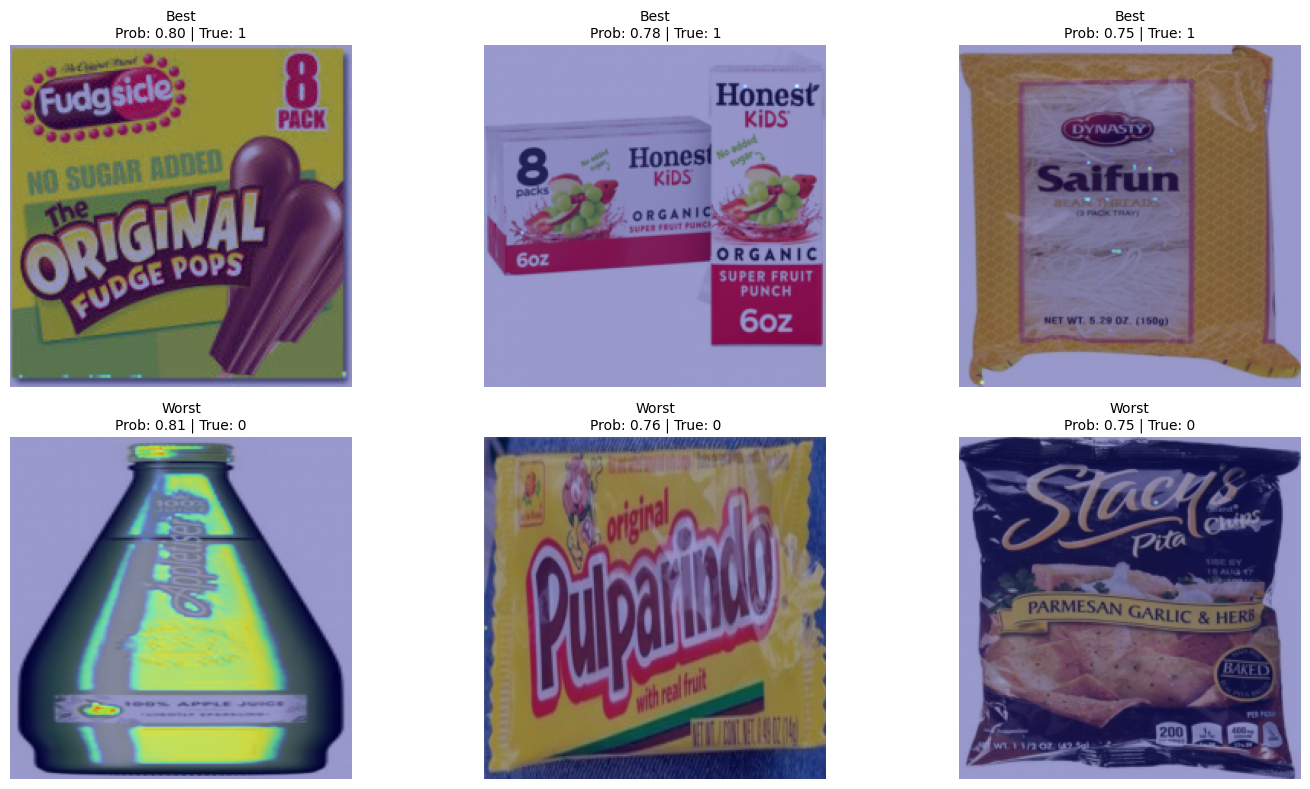


Generating Grad-CAM for: ResNet-18 (Learned)


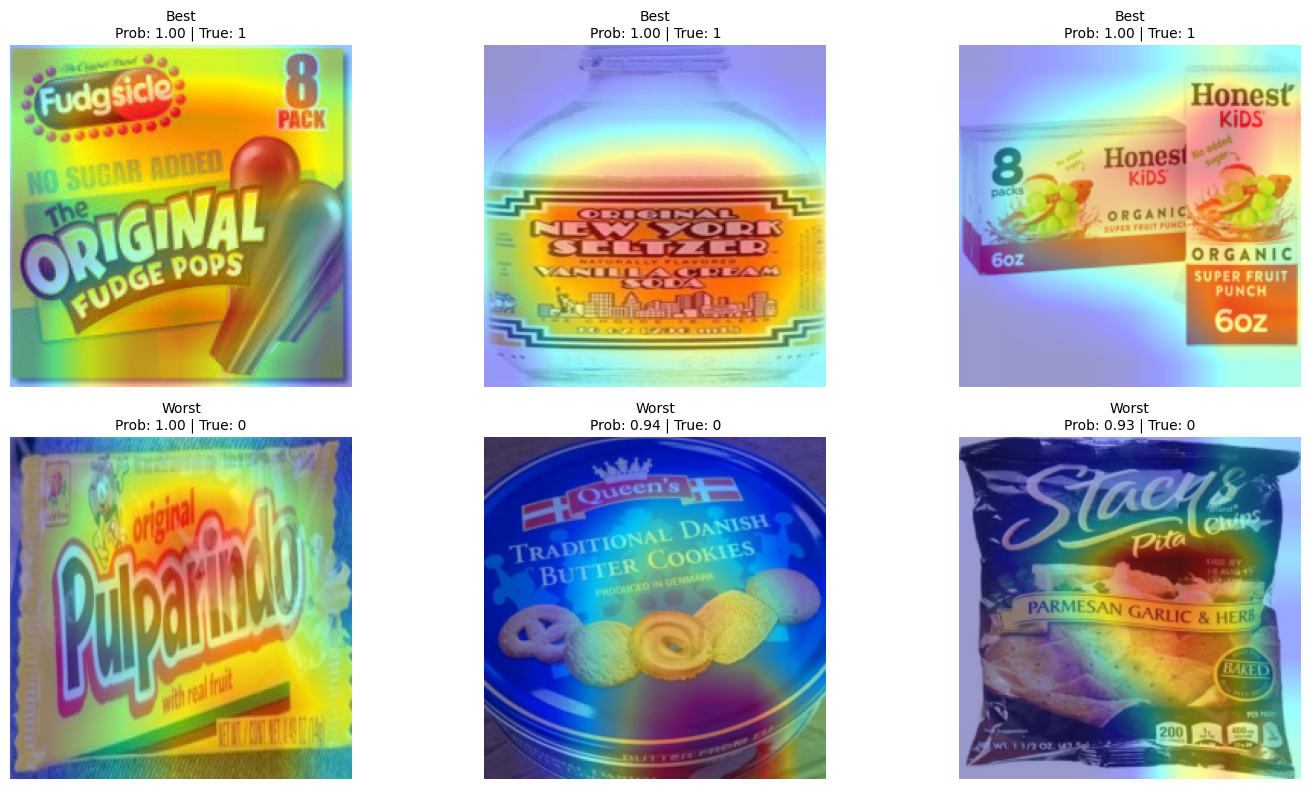


Generating Grad-CAM for: ResNet-18 (Fine-Tuned)


C:\Users\Colton\AppData\Local\Temp\ipykernel_11488\2409974961.py:49: RuntimeWarning: invalid value encountered in cast
  heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
C:\Users\Colton\AppData\Local\Temp\ipykernel_11488\2409974961.py:49: RuntimeWarning: invalid value encountered in cast
  heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)


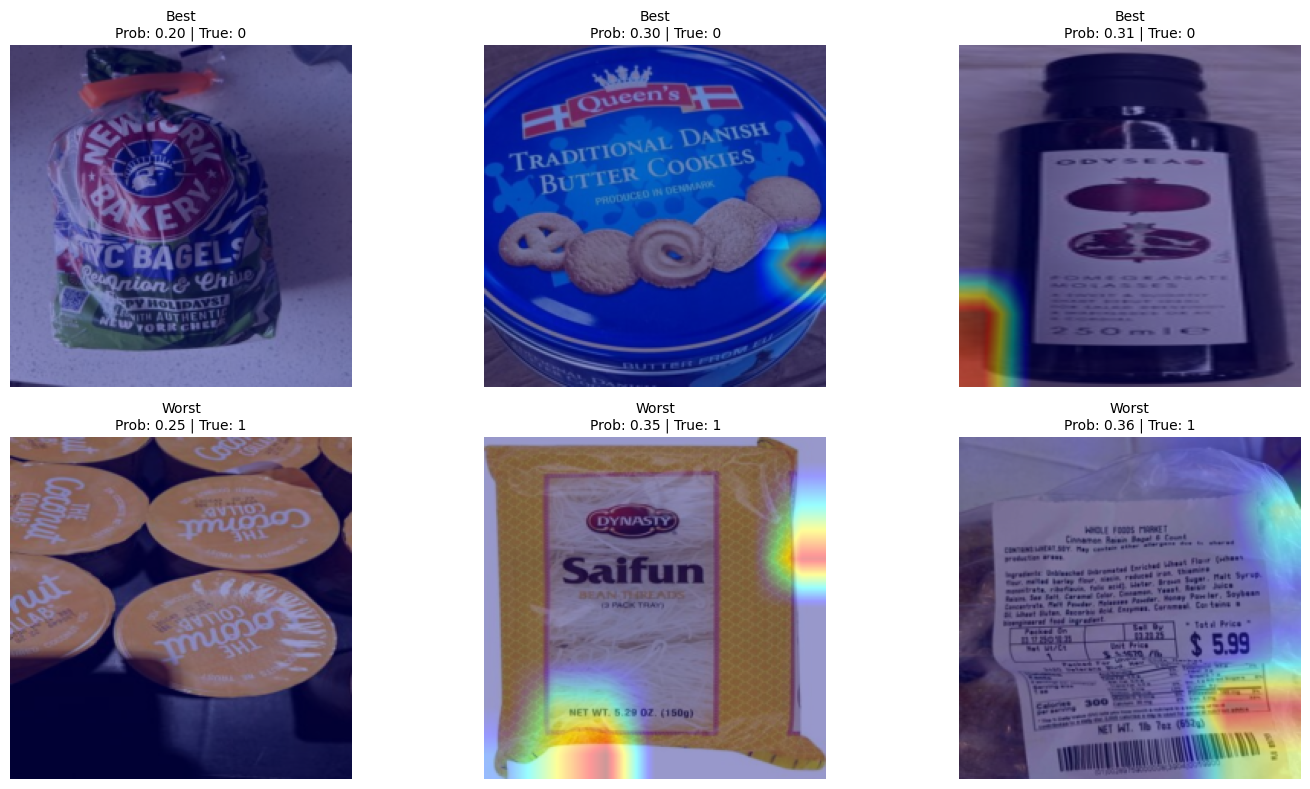

In [13]:
def run_full_gradcam_analysis(model, model_name, target_layer, n=3):
    print(f"\nGenerating Grad-CAM for: {model_name}")
    cam = GradCAM(model, target_layer)
    best_idx, worst_idx = get_best_worst_indices(model, test_loader, n=n)
    
    fig, axes = plt.subplots(2, n, figsize=(15, 8))
    
    for i, (idx_list, label_type) in enumerate([(best_idx, "Best"), (worst_idx, "Worst")]):
        for j, row in enumerate(idx_list.to_dict('records')):
            # Get data from test_loader (requires re-indexing or grabbing from dataset)
            # Simplest way: get from the dataset used in the loader
            img_tensor, _ = test_loader.dataset[int(row['index'])]
            input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
            
            heatmap = cam.generate_heatmap(input_tensor)
            
            plt.subplot(2, n, i * n + j + 1)
            title = f"{label_type}\nProb: {row['prob']:.2f} | True: {int(row['label'])}"
            plot_gradcam(img_tensor, heatmap, title)
            
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# 1. Custom CNN (Target the last conv layer)
run_full_gradcam_analysis(model_cnn, "Custom CNN", model_cnn.conv_layers[3], n=3)

# 2. ResNet-18 Learned (Target layer4)
run_full_gradcam_analysis(model_rn18_scratch, "ResNet-18 (Learned)", model_rn18_scratch.layer4, n=3)

# 3. ResNet-18 Fine-Tuned (Target layer4)
run_full_gradcam_analysis(model_rn18_ft, "ResNet-18 (Fine-Tuned)", model_rn18_ft.layer4, n=3)